# 📈 Tahap 3: Analisis Eksplorasi Lanjutan, Pelabelan Sentimen, & Visualisasi Kata
**Proyek:** Sistem Rekomendasi & Analisis Sentimen Pariwisata Kabupaten Garut  
**Tujuan:**
1. Menerapkan pelabelan sentimen berbasis rating (*rating-based sentiment labeling*).
2. Mengeksplorasi distribusi rating dan sentimen (Positif, Netral, Negatif) dalam **Tabel Statistik & Grafik**.
3. Menganalisis statistik leksikal (panjang karakter, jumlah kata, reduksi ukuran kosa kata sebelum vs sesudah).
4. Menghasilkan visualisasi **WordCloud** untuk masing-masing kelas sentimen.
5. Mengekstraksi **Tabel Top N-Grams (Unigram & Bigram)** per sentimen.
6. Menganalisis **Tabel Proporsi Sentimen per Destinasi Wisata** di Kabupaten Garut.


In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings
from sentiment.labeling import apply_sentiment_labeling, get_label_from_rating

print(f"✅ Root Directory: {ROOT_DIR}")
print("Modul analisis & visualisasi siap.")


✅ Root Directory: /Users/macbook/Garut-Tourism-Reccomendation
Modul analisis & visualisasi siap.


## 1. Pemuatan Dataset & Pelabelan Sentimen

### Aturan Pemetaan Sentimen Berdasarkan Rating:
- **Rating 1.0 - 2.0** $
ightarrow$ **Negatif (0)**
- **Rating 3.0** $
ightarrow$ **Netral (1)**
- **Rating 4.0 - 5.0** $
ightarrow$ **Positif (2)**


In [2]:
processed_path = settings.FINAL_DATA_DIR / "processed_reviews.csv"
if not processed_path.exists():
    raise FileNotFoundError("processed_reviews.csv belum ada. Jalankan notebook 02 terlebih dahulu.")

df = pd.read_csv(processed_path)
df = apply_sentiment_labeling(df)

sentiment_names = {0: "Negatif", 1: "Netral", 2: "Positif"}
df["sentiment_name"] = df["sentiment_label"].map(sentiment_names)

print(f"Total ulasan terproses & terlabeli: {len(df):,} baris")


Total ulasan terproses & terlabeli: 17,923 baris


## 2. Distribusi Rating dan Sentimen Ulasan

In [3]:
# TABEL DISTRIBUSI KELAS SENTIMEN
sentiment_counts = df["sentiment_name"].value_counts().reindex(["Positif", "Netral", "Negatif"])

tabel_sentimen = pd.DataFrame({
    "Kelas Sentimen": sentiment_counts.index,
    "Rentang Rating Terkait": ["4.0 s/d 5.0 Bintang", "3.0 Bintang", "1.0 s/d 2.0 Bintang"],
    "Jumlah Ulasan": [f"{v:,}" for v in sentiment_counts.values],
    "Persentase (%)": [f"{(v/len(df))*100:.2f}%" for v in sentiment_counts.values]
})
display(tabel_sentimen)


,Kelas Sentimen,Rentang Rating Terkait,Jumlah Ulasan,Persentase (%)
0,Positif,4.0 s/d 5.0 Bintang,"15,553",86.78%
1,Netral,3.0 Bintang,819,4.57%
2,Negatif,1.0 s/d 2.0 Bintang,"1,551",8.65%


In [4]:
# TABEL DISTRIBUSI BINTANG RATING INDIVIDUAL (1 - 5)
rating_table = df["rating"].value_counts().sort_index().reset_index()
rating_table.columns = ["Bintang Rating", "Jumlah Ulasan"]
rating_table["Sentimen Terpetakan"] = rating_table["Bintang Rating"].apply(lambda r: sentiment_names[get_label_from_rating(r)])
rating_table["Persentase"] = [(v / len(df)) * 100 for v in rating_table["Jumlah Ulasan"]]
rating_table["Persentase"] = rating_table["Persentase"].map("{:.2f}%".format)
display(rating_table)


,Bintang Rating,Jumlah Ulasan,Sentimen Terpetakan,Persentase
0,1.0,1143,Negatif,6.38%
1,2.0,408,Negatif,2.28%
2,3.0,818,Netral,4.56%
3,3.5,1,Netral,0.01%
4,4.0,2254,Positif,12.58%
5,4.2,1,Positif,0.01%
6,4.5,1,Positif,0.01%
7,5.0,13297,Positif,74.19%


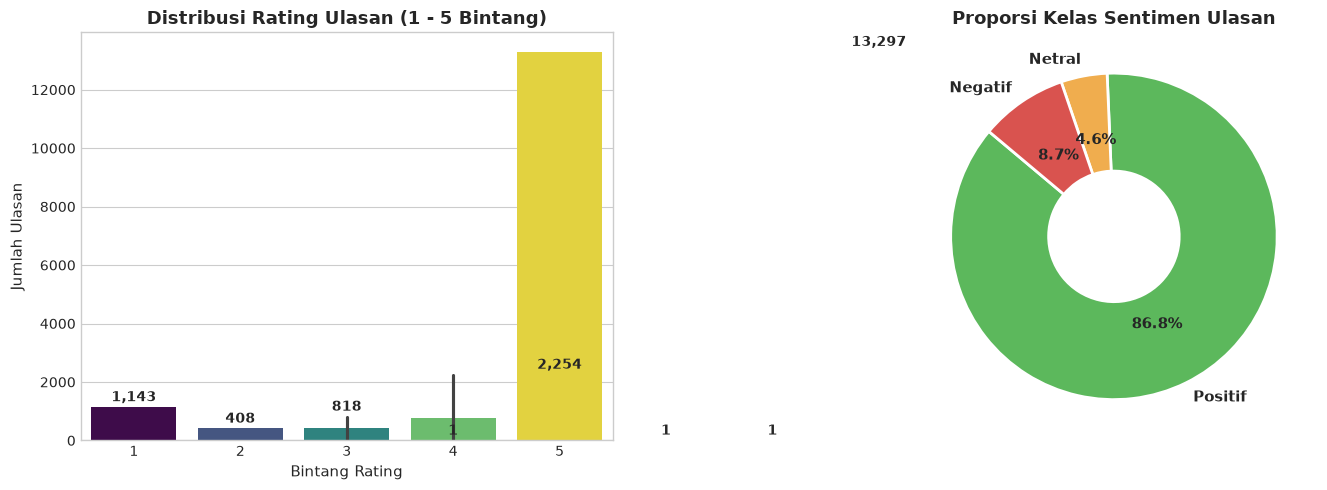

In [5]:
# Visualisasi Distribusi Rating & Sentimen
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# 1. Rating Bar Plot
r_counts = df["rating"].value_counts().sort_index()
sns.barplot(x=r_counts.index.astype(int), y=r_counts.values, hue=r_counts.index.astype(int), legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Distribusi Rating Ulasan (1 - 5 Bintang)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Bintang Rating", fontsize=11)
axes[0].set_ylabel("Jumlah Ulasan", fontsize=11)
for i, v in enumerate(r_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold", fontsize=10)

# 2. Sentiment Pie Chart
colors = ["#5cb85c", "#f0ad4e", "#d9534f"]
axes[1].pie(
    sentiment_counts.values, 
    labels=sentiment_counts.index, 
    autopct="%1.1f%%", 
    startangle=140, 
    colors=colors,
    wedgeprops=dict(width=0.6, edgecolor='w', linewidth=2),
    textprops=dict(fontsize=11, fontweight="bold")
)
axes[1].set_title("Proporsi Kelas Sentimen Ulasan", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 3. Analisis Leksikal & Reduksi Ukuran Kosa Kata (*Vocabulary Size*)

In [6]:
df["raw_word_count"] = df["review_text"].astype(str).apply(lambda x: len(x.split()))
df["clean_word_count"] = df["cleaned_text"].astype(str).apply(lambda x: len(x.split()))

raw_vocab = set(" ".join(df["review_text"].astype(str)).lower().split())
clean_vocab = set(" ".join(df["cleaned_text"].astype(str)).split())

# TABEL PERBANDINGAN SEBELUM VS SESUDAH PREPROCESSING
lexical_comparison_table = pd.DataFrame([
    {"Metrik Leksikal": "Total Kosa Kata Unik (Unique Vocabulary Size)", "Sebelum Preprocessing (Raw)": f"{len(raw_vocab):,} kata", "Sesudah Preprocessing (Cleaned)": f"{len(clean_vocab):,} kata dasar", "Perubahan / Reduksi": f"-{len(raw_vocab) - len(clean_vocab):,} kata ({((len(raw_vocab)-len(clean_vocab))/len(raw_vocab))*100:.2f}%)"},
    {"Metrik Leksikal": "Rata-rata Jumlah Kata per Review", "Sebelum Preprocessing (Raw)": f"{df['raw_word_count'].mean():.2f} kata", "Sesudah Preprocessing (Cleaned)": f"{df['clean_word_count'].mean():.2f} kata", "Perubahan / Reduksi": f"-{df['raw_word_count'].mean() - df['clean_word_count'].mean():.2f} kata ({((df['raw_word_count'].mean() - df['clean_word_count'].mean())/df['raw_word_count'].mean())*100:.2f}%)"},
    {"Metrik Leksikal": "Panjang Kata Maksimum dalam 1 Review", "Sebelum Preprocessing (Raw)": f"{df['raw_word_count'].max():,} kata", "Sesudah Preprocessing (Cleaned)": f"{df['clean_word_count'].max():,} kata", "Perubahan / Reduksi": f"-{df['raw_word_count'].max() - df['clean_word_count'].max():,} kata"}
])
display(lexical_comparison_table)


,Metrik Leksikal,Sebelum Preprocessing (Raw),Sesudah Preprocessing (Cleaned),Perubahan / Reduksi
0,Total Kosa Kata Unik (Unique Vocabulary Size),"37,480 kata","15,889 kata dasar","-21,591 kata (57.61%)"
1,Rata-rata Jumlah Kata per Review,21.71 kata,13.55 kata,-8.16 kata (37.58%)
2,Panjang Kata Maksimum dalam 1 Review,510 kata,298 kata,-212 kata


## 4. Visualisasi WordCloud per Kelas Sentimen

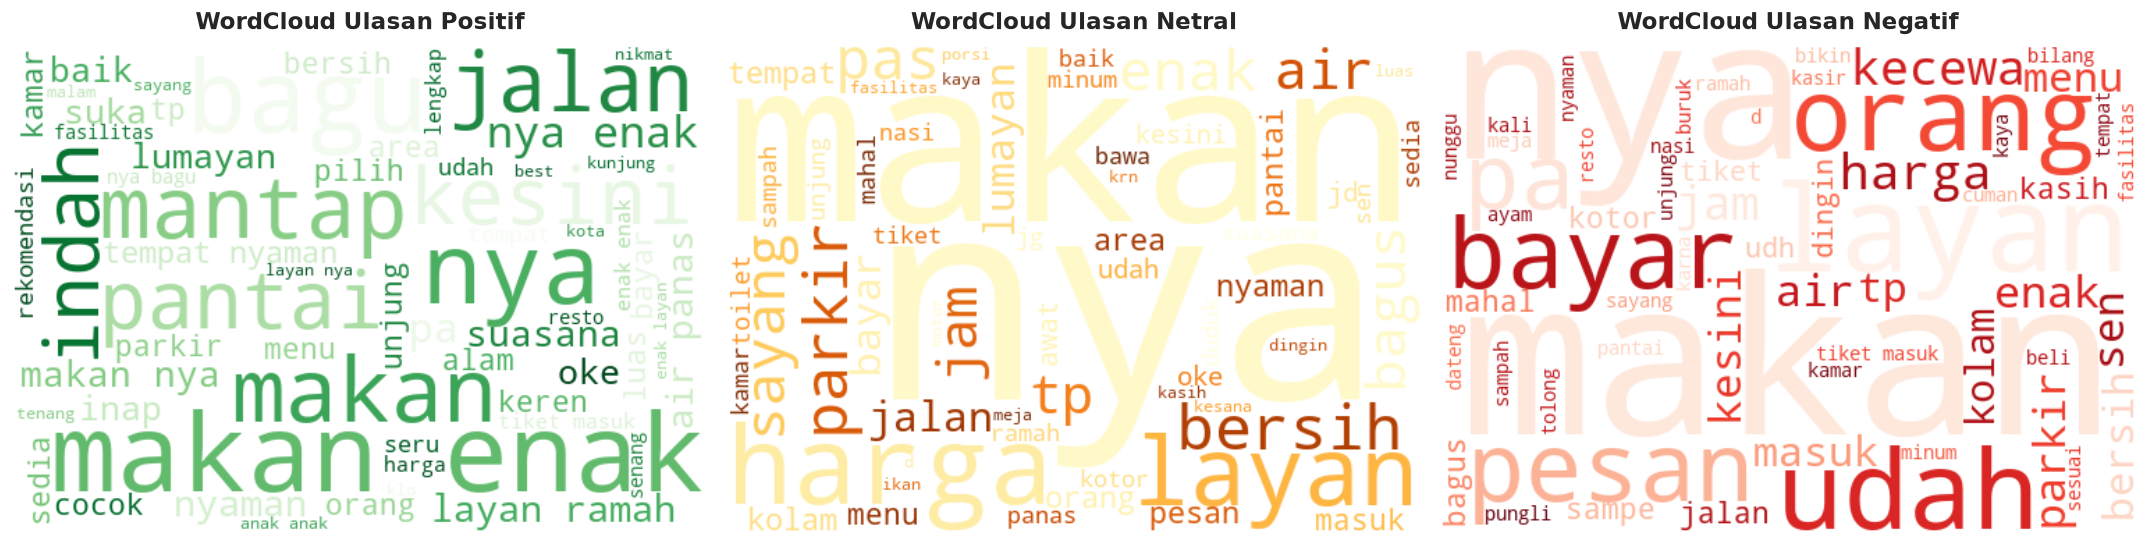

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=120)

configs = [
    ("Positif", "#28a745", "Greens", 2),
    ("Netral", "#ffc107", "YlOrBr", 1),
    ("Negatif", "#dc3545", "Reds", 0)
]

for ax, (label_name, color, cmap, label_val) in zip(axes, configs):
    subset_text = " ".join(df[df["sentiment_label"] == label_val]["cleaned_text"].dropna())
    
    if subset_text.strip():
        wc = WordCloud(
            width=500, 
            height=350, 
            background_color="white", 
            colormap=cmap, 
            max_words=60, 
            random_state=42
        ).generate(subset_text)
        
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"WordCloud Ulasan {label_name}", fontsize=14, fontweight="bold", pad=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Analisis N-Gram: Kata Kunci (Unigrams & Bigrams) per Sentimen

In [8]:
def get_top_ngrams(corpus, ngram_range=(1, 1), top_n=10):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_n], columns=["Kata / Pasangan Frasa", "Frekuensi"])

# Ekstraksi Top Unigrams per Sentimen
df_uni_pos = get_top_ngrams(df[df["sentiment_label"] == 2]["cleaned_text"].dropna(), (1, 1), 10)
df_uni_net = get_top_ngrams(df[df["sentiment_label"] == 1]["cleaned_text"].dropna(), (1, 1), 10)
df_uni_neg = get_top_ngrams(df[df["sentiment_label"] == 0]["cleaned_text"].dropna(), (1, 1), 10)

# TABEL TOP 10 UNIGRAM PER KELAS SENTIMEN
tabel_unigram = pd.DataFrame({
    "No": range(1, 11),
    "Positif (Kata)": df_uni_pos["Kata / Pasangan Frasa"], "Freq Positif": df_uni_pos["Frekuensi"],
    "Netral (Kata)": df_uni_net["Kata / Pasangan Frasa"], "Freq Netral": df_uni_net["Frekuensi"],
    "Negatif (Kata)": df_uni_neg["Kata / Pasangan Frasa"], "Freq Negatif": df_uni_neg["Frekuensi"]
})
display(tabel_unigram)


,No,Positif (Kata),Freq Positif,Netral (Kata),Freq Netral,Negatif (Kata),Freq Negatif
0,1,makan,5587,makan,429,makan,869
1,2,nya,4786,nya,379,nya,660
2,3,enak,4587,harga,150,layan,401
3,4,bagus,2526,bagus,140,jam,333
4,5,nyaman,2377,enak,138,bayar,275
5,6,tempat,1978,layan,123,masuk,254
6,7,layan,1849,parkir,123,udah,240
7,8,pantai,1792,air,116,tiket,234
8,9,ramah,1611,bersih,113,harga,227
9,10,bersih,1579,sayang,111,parkir,227


In [9]:
# Ekstraksi Top Bigrams per Sentimen
df_bi_pos = get_top_ngrams(df[df["sentiment_label"] == 2]["cleaned_text"].dropna(), (2, 2), 10)
df_bi_net = get_top_ngrams(df[df["sentiment_label"] == 1]["cleaned_text"].dropna(), (2, 2), 10)
df_bi_neg = get_top_ngrams(df[df["sentiment_label"] == 0]["cleaned_text"].dropna(), (2, 2), 10)

# TABEL TOP 10 BIGRAM PER KELAS SENTIMEN
tabel_bigram = pd.DataFrame({
    "No": range(1, 11),
    "Positif (Frasa Bigram)": df_bi_pos["Kata / Pasangan Frasa"], "Freq Pos": df_bi_pos["Frekuensi"],
    "Netral (Frasa Bigram)": df_bi_net["Kata / Pasangan Frasa"], "Freq Net": df_bi_net["Frekuensi"],
    "Negatif (Frasa Bigram)": df_bi_neg["Kata / Pasangan Frasa"], "Freq Neg": df_bi_neg["Frekuensi"]
})
display(tabel_bigram)


,No,Positif (Frasa Bigram),Freq Pos,Netral (Frasa Bigram),Freq Net,Negatif (Frasa Bigram),Freq Neg
0,1,makan enak,1233,kamar mandi,33,tiket masuk,87
1,2,nya enak,567,makan enak,33,makan enak,47
2,3,layan ramah,501,tiket masuk,25,layan nya,40
3,4,air panas,452,makan nya,22,nunggu jam,37
4,5,makan nya,449,air panas,20,makan nya,36
5,6,tempat nyaman,402,makan minum,15,makan jam,34
6,7,tiket masuk,311,kolam renang,15,nunggu makan,30
7,8,enak enak,286,tempat bagus,15,worth it,30
8,9,layan nya,279,pantai nya,14,bayar tiket,30
9,10,nya bagus,274,nya bagus,13,jam makan,30


## 6. Analisis Distribusi Sentimen per Destinasi Wisata

In [10]:
top10_dest_names = df["destination_name"].value_counts().head(10).index
df_top10 = df[df["destination_name"].isin(top10_dest_names)]

dest_sentiment = pd.crosstab(
    df_top10["destination_name"], 
    df_top10["sentiment_name"], 
    normalize="index"
) * 100

dest_sentiment = dest_sentiment.reindex(columns=["Negatif", "Netral", "Positif"])

# TABEL SENTIMEN PER DESTINASI TOP 10
tabel_dest_sent = dest_sentiment.copy()
tabel_dest_sent["Total Ulasan"] = df_top10.groupby("destination_name")["rating"].count()
tabel_dest_sent["Rating Rata-rata"] = df_top10.groupby("destination_name")["rating"].mean().round(2)
tabel_dest_sent["% Positif"] = tabel_dest_sent["Positif"].map("{:.1f}%".format)
tabel_dest_sent["% Netral"] = tabel_dest_sent["Netral"].map("{:.1f}%".format)
tabel_dest_sent["% Negatif"] = tabel_dest_sent["Negatif"].map("{:.1f}%".format)

display(tabel_dest_sent[["Total Ulasan", "Rating Rata-rata", "% Positif", "% Netral", "% Negatif"]].sort_values("Total Ulasan", ascending=False))


sentiment_name,Total Ulasan,Rating Rata-rata,% Positif,% Netral,% Negatif
destination_name,,,,,
Kampung Muara Sunda,402,3.74,66.7%,4.0%,29.4%
Ramenkane Cikuray Garut,398,4.95,99.2%,0.5%,0.3%
"RM Saung Cikenceh (Garut Kota, Cikuray)",383,4.73,94.3%,0.8%,5.0%
Bumi Upi,375,4.39,82.4%,8.0%,9.6%
"Joglo Abah Resto, Kedai Kopi dan Pusat Oleh-oleh",370,4.89,97.3%,0.8%,1.9%
Garland Barnville,350,4.40,83.7%,5.4%,10.9%
Botram Garut,349,4.55,88.0%,4.6%,7.4%
Glamping Villa by Sabda Alam,333,4.90,97.6%,1.5%,0.9%
Ramen Gorilla,311,4.76,93.2%,2.9%,3.9%


In [11]:
# Simpan dataset lengkap dengan label sentimen
labeled_output_path = settings.FINAL_DATA_DIR / "labeled_reviews.csv"
export_cols = ["destination_name", "author", "rating", "review_text", "cleaned_text", "sentiment_label", "sentiment_name"]
df[export_cols].to_csv(labeled_output_path, index=False)
print(f"✅ Data ulasan berlabel sentimen berhasil disimpan ke: {labeled_output_path}")


✅ Data ulasan berlabel sentimen berhasil disimpan ke: /Users/macbook/Garut-Tourism-Reccomendation/data/final/labeled_reviews.csv
